<a href="https://colab.research.google.com/github/ShannonH98/PyTorch_Practice_Projects/blob/main/Neural_Networks_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [2]:
X = [0,1]
w1 = [2,3]
w2 = [0.4, 1.8]


In [5]:
dot_X_w1 = X[0] * w1[0] + X[1] * w1[1]
dot_X_w1

3

In [6]:
dot_X_w2 = X[0] * w2[0] + X[1] * w2[1]
dot_X_w2

1.8

In [7]:
#or

np.dot(X,w1)

np.int64(3)

In [8]:
np.dot(X,w2)

np.float64(1.8)

In [30]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iamsouravbanerjee/heart-attack-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-attack-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/heart-attack-prediction-dataset


In [31]:
path

'/kaggle/input/heart-attack-prediction-dataset'

In [32]:
!ls /root/.cache/kagglehub/datasets/iamsouravbanerjee/heart-attack-prediction-dataset/versions/2

heart_attack_prediction_dataset.csv


In [38]:
df = pd.read_csv(path + '/heart_attack_prediction_dataset.csv')

In [44]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [43]:
X = np.array(df.loc[:, df.columns != 'Heart Attack Risk'])
y = np.array(df['Heart Attack Risk'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (8763, 25)
y shape: (8763,)


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
# Identify numerical columns from the original DataFrame df, excluding the target variable
# and then filter X_train and X_test to keep only these numerical columns.
numeric_cols_in_df = df.drop(columns=['Heart Attack Risk']).select_dtypes(include=np.number).columns
original_X_columns = df.drop(columns=['Heart Attack Risk']).columns

# Get the indices of the numerical columns that are present in the original X
numeric_indices = [original_X_columns.get_loc(col) for col in numeric_cols_in_df]

# Filter X_train and X_test to keep only numerical columns by index
X_train_numeric = X_train[:, numeric_indices]
X_test_numeric = X_test[:, numeric_indices]

scalar = StandardScaler()
X_train_scale = scalar.fit_transform(X_train_numeric)
X_test_scale = scalar.transform(X_test_numeric)

In [64]:
import numpy as np # Adding import here since it's used extensively

class NeuralNetwork:
  def __init__(self, learningRate, X_train, y_train, X_test, y_test):
    self.w = np.random.randn(X_train.shape[1]) # w should match X_train dimensions
    self.b = np.random.randn(1) # Initialize bias
    self.learningRate = learningRate
    self.X_train = X_train
    self.y_train = y_train
    self.X_test = X_test
    self.y_test = y_test
    self.L_train = []
    self.L_test = []

  def activation(self, x):
    # sigmoid
    return 1 / (1+np.exp(-x))

  def deactivation(self, x):
    # Derivative of sigmoid activation function
    act_x = self.activation(x)
    return act_x * (1 - act_x)

  def forward(self, X):
    hidden_1 = np.dot(X, self.w) + self.b
    activate_1 = self.activation(hidden_1)
    return activate_1

  def backward(self, X, y_true):
    #calculating the gradients
    hidden_1 = np.dot(X, self.w) + self.b
    y_pred = self.forward(X)
    dL_dpred = 2 * (y_pred - y_true)
    dpred_dhidden1 = self.deactivation(hidden_1)
    dhidden1_db = 1
    dhidden1_dw = X

    dL_db = dL_dpred * dpred_dhidden1 * dhidden1_db
    dL_dw = dL_dpred * dpred_dhidden1 * dhidden1_dw
    return dL_db, dL_dw

  def optimizer(self, dL_db, dL_dw):
    self.b = self.b - self.learningRate * dL_db
    self.w = self.w - self.learningRate * dL_dw

  def train(self, epochs):
    for epoch in range(epochs):
      random_pos = np.random.randint(len(self.X_train))

      #forward pass for training data
      y_train_true = self.y_train[random_pos] # Corrected: use self.y_train
      y_pred_train = self.forward(self.X_train[random_pos]) # Renamed y_pred to y_pred_train for clarity

      # calculate training losses
      L = np.sum(np.square(y_pred_train - y_train_true))
      self.L_train.append(L)

      #calculate gradients
      dL_db, dL_dw = self.backward(self.X_train[random_pos], y_train_true)

      #update weights
      self.optimizer(dL_db, dL_dw)

      #calc error for test data
      L_sum_test = 0 # Renamed L_sum to L_sum_test for clarity
      for j in range(len(self.X_test)):
        y_true_test = self.y_test[j]
        y_pred_test = self.forward(self.X_test[j])
        L_test = np.sum(np.square(y_pred_test - y_true_test))
        L_sum_test += L_test
      self.L_test.append(L_sum_test) # Corrected typo: L.self.L_test.append to self.L_test.append
    return 'training successful'

In [58]:
LR = 0.1
epochs = 1000

In [65]:
nn = NeuralNetwork(learningRate=LR,
                   X_train=X_train_scale,
                   y_train=y_train,
                   X_test=X_test_scale,
                   y_test=y_test)

nn.train(epochs=epochs)

'training successful'

<Axes: >

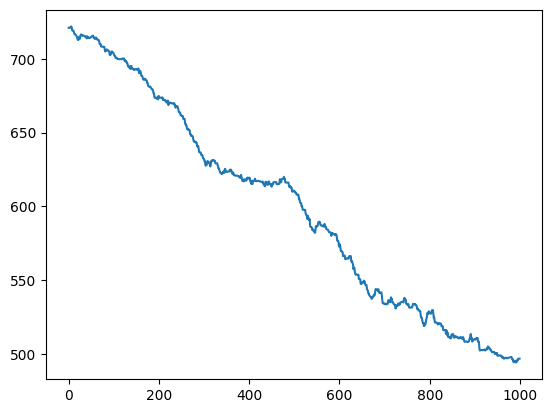

In [67]:
sns.lineplot(x = list(range(len(nn.L_test))), y = nn.L_test)

In [70]:
total = X_test_scale.shape[0]
correct = 0
y_preds = []
for i in range(total):
  y_true = y_test[i]
  y_pred = np.round(nn.forward(X_test_scale[i]))
  y_preds.append(y_pred)
  correct += 1 if y_true == y_pred else 0

In [71]:
correct/total

0.6160867084997148

In [72]:
from collections import Counter

Counter(y_test)

Counter({np.int64(0): 1125, np.int64(1): 628})

In [73]:
confusion_matrix(y_true=y_test, y_pred=y_preds)

array([[1028,   97],
       [ 576,   52]])